In [1]:
import json

with open("corpus_lemmatized.json", "r", encoding="utf-8") as f:
    lemmas = json.load(f)


In [2]:
from collections import Counter

def get_corpus_frequencies(corpus_dict):
    all_lemmas = []

    for lemmas in corpus_dict.values():
        all_lemmas.extend(lemmas)

    freq = Counter(all_lemmas)

    return freq

corpus_frequencies = get_corpus_frequencies(lemmas)
for i in range(200):
    print(corpus_frequencies.most_common()[i])

# print(corpus_frequencies["إسلام"])

('قال', 3428)
('الله', 819)
('أمر', 582)
('الملك', 571)
('كلام', 493)
('يوم', 485)
('دخل', 477)
('وزير', 464)
('سمع', 426)
('مكان', 418)
('ملك', 398)
('شيء', 362)
('شركان', 339)
('قلت', 317)
('خرج', 311)
('جاري', 305)
('يد', 305)
('نظر', 290)
('رجل', 274)
('رأس', 259)
('ليلة', 253)
('باب', 251)
('حسن', 245)
('أخي', 240)
('فلما', 240)
('ضوء', 228)
('إنسان', 221)
('بيت', 218)
('فعل', 216)
('أرض', 208)
('قتل', 206)
('قلب', 205)
('مدينة', 202)
('جرى', 199)
('زمان', 199)
('أراد', 197)
('صاحب', 195)
('لأن', 192)
('أكل', 190)
('ضرب', 188)
('جاء', 188)
('نزل', 188)
('قدم', 187)
('تاجر', 186)
('آخر', 185)
('سبب', 185)
('ليل', 179)
('ساعة', 178)
('سلطان', 178)
('وجه', 177)
('أتى', 172)
('دين', 168)
('نور', 168)
('ولد', 168)
('أمير', 167)
('حال', 166)
('مال', 162)
('عرف', 159)
('بن', 157)
('جلس', 155)
('عسكر', 154)
('دار', 152)
('زال', 151)
('قصر', 151)
('ابن', 151)
('شاب', 151)
('سنة', 149)
('أنشد', 148)
('عمر', 148)
('وقت', 147)
('أرسل', 146)
('وصل', 145)
('مسلم', 145)
('فرح', 144)
('طلع', 143)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

def compute_tfidf(corpus_dict):
    docs = [" ".join(lemmas) for lemmas in corpus_dict.values()]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(docs)

    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=corpus_dict.keys()
    )
    return tfidf_df

def get_top_tfidf_words(tfidf_df, top_n=10):
    top_words = {}
    for doc in tfidf_df.index:
        top_terms = (tfidf_df.loc[doc].sort_values(ascending=False).head(top_n).index.tolist())
        top_words[doc] = top_terms
    return top_words

def print_top_tfidf_words(top_words, tfidf_df):
    for doc, words in top_words.items():
        print(f"Document: {doc}")
        for word in words:
            print(f"Score: {tfidf_df.loc[doc, word]:.4f} - Word: {word}")

tfidf_df = compute_tfidf(lemmas)
top_words = get_top_tfidf_words(tfidf_df, top_n=10)
print_top_tfidf_words(top_words, tfidf_df)

Document: chapter_0
Score: 0.2672 - Word: قال
Score: 0.2521 - Word: فقال
Score: 0.2117 - Word: شهريار
Score: 0.2117 - Word: ثور
Score: 0.1498 - Word: شاه
Score: 0.1493 - Word: حمار
Score: 0.1344 - Word: تاجر
Score: 0.1335 - Word: أخيه
Score: 0.1306 - Word: الملك
Score: 0.1123 - Word: شجرة
Document: chapter_1
Score: 0.2685 - Word: تاجر
Score: 0.2130 - Word: شيخ
Score: 0.2033 - Word: العفريت
Score: 0.1880 - Word: غزالة
Score: 0.1880 - Word: الغزالة
Score: 0.1780 - Word: قال
Score: 0.1500 - Word: تمرة
Score: 0.1500 - Word: نواة
Score: 0.1500 - Word: راعي
Score: 0.1500 - Word: بقرة
Document: chapter_2
Score: 0.2390 - Word: عجل
Score: 0.2313 - Word: قال
Score: 0.2125 - Word: راعي
Score: 0.2100 - Word: قلت
Score: 0.1898 - Word: الجني
Score: 0.1598 - Word: أخوي
Score: 0.1358 - Word: سفر
Score: 0.1351 - Word: ربح
Score: 0.1331 - Word: زوجة
Score: 0.1275 - Word: الراعي
Document: chapter_3
Score: 0.3545 - Word: قال
Score: 0.2985 - Word: الصياد
Score: 0.2459 - Word: العفريت
Score: 0.2403 - Word: 

In [4]:
power_words = ["الملك", "ملك", "سلطان", "أمير", "خليفة", "الخليفة", "عسكر"]
religion_words = ["الله", "الدين", "دين", "مسلم", "مؤمن", "كفار", "إسلام"]

Power-related words frequencies:
الملك: 571
ملك: 398
سلطان: 178
أمير: 167
عسكر: 154
خليفة: 137
الخليفة: 81

Religion-related words frequencies:
الله: 819
دين: 168
مسلم: 145
الدين: 141
مؤمن: 100
كفار: 91
إسلام: 30


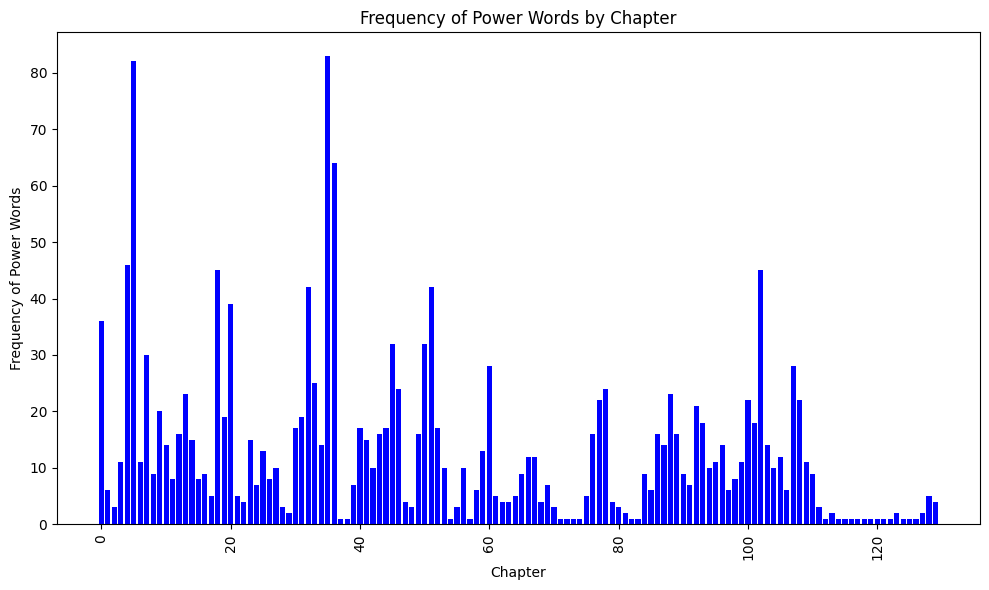

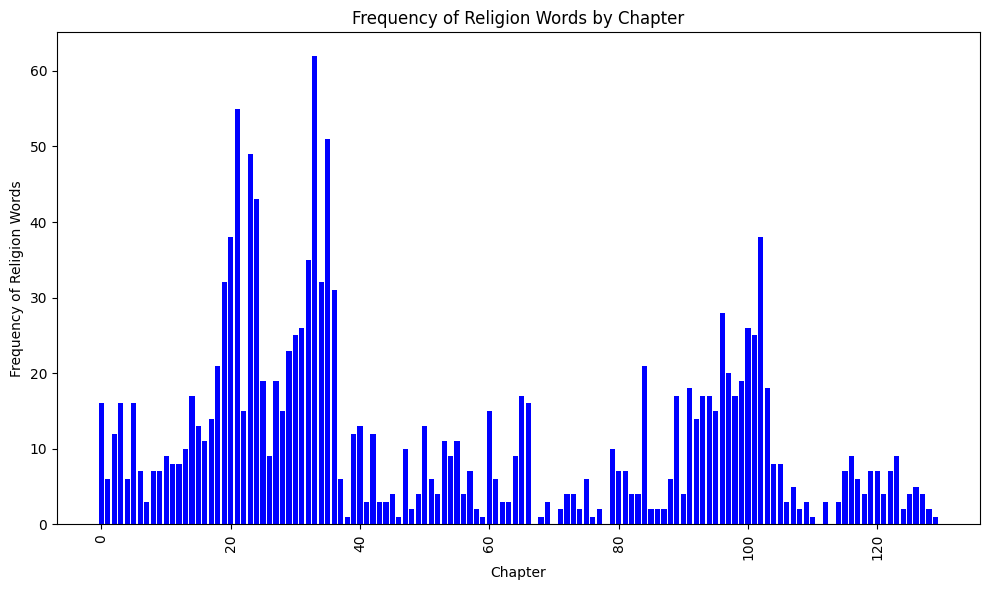

In [5]:
import matplotlib.pyplot as plt

def get_corpus_theme_by_document(corpus_dict, theme_words):
    theme_freq_by_doc = {}

    for doc_id, lemmas in corpus_dict.items():
        theme_freq = Counter()
        for word in lemmas:
            if word in theme_words:
                theme_freq[word] += 1
        theme_freq_by_doc[doc_id] = theme_freq

    return theme_freq_by_doc

def plot_theme_frequencies_by_document(theme_freq_by_doc, theme_name):
    theme_counts = [sum(freq.values()) for freq in theme_freq_by_doc.values()]
    doc_ids = list(range(len(theme_counts)))

    plt.figure(figsize=(10, 6))
    plt.bar(doc_ids, theme_counts, color='blue')
    plt.xlabel('Chapter')
    plt.ylabel(f'Frequency of {theme_name} Words')
    plt.title(f'Frequency of {theme_name} Words by Chapter')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"concept_word_images/{theme_name}_by_chapter.png", dpi=500)
    plt.show()


def get_corpus_theme_occurences(corpus_dict, theme_words):
    theme_freq = Counter()

    for lemmas in corpus_dict.values():
        for word in lemmas:
            if word in theme_words:
                theme_freq[word] += 1

    return theme_freq

power_freq = get_corpus_theme_occurences(lemmas, power_words)
religion_freq = get_corpus_theme_occurences(lemmas, religion_words)
print("Power-related words frequencies:")
for word, freq in sorted(power_freq.items(), key=lambda x: x[1], reverse=True):
    print(f"{word}: {freq}")

print()

print("Religion-related words frequencies:")
for word, freq in sorted(religion_freq.items(), key=lambda x: x[1], reverse=True):
    print(f"{word}: {freq}")

power_freq_by_doc = get_corpus_theme_by_document(lemmas, power_words)
religion_freq_by_doc = get_corpus_theme_by_document(lemmas, religion_words)
plot_theme_frequencies_by_document(power_freq_by_doc, "Power")
plot_theme_frequencies_by_document(religion_freq_by_doc, "Religion")

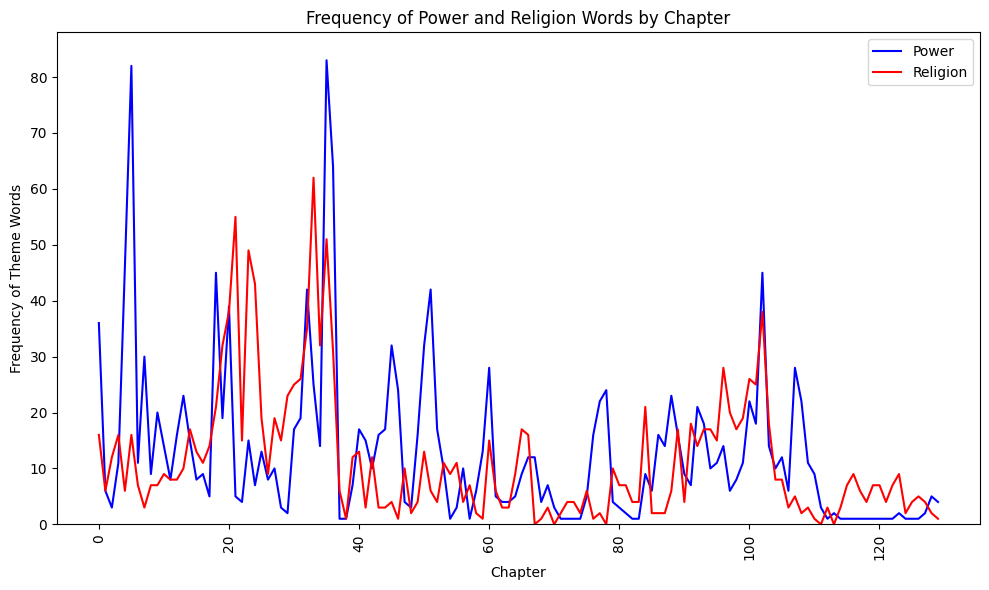

In [6]:
def plot_2_themes_by_document(theme_freq_by_doc1, theme_freq_by_doc2, theme_name1, theme_name2):
    theme_counts1 = [sum(freq.values()) for freq in theme_freq_by_doc1.values()]
    theme_counts2 = [sum(freq.values()) for freq in theme_freq_by_doc2.values()]
    doc_ids = list(range(len(theme_counts1)))

    plt.figure(figsize=(10, 6))
    plt.plot(doc_ids, theme_counts1, color='blue', label=theme_name1)
    plt.plot(doc_ids, theme_counts2, color='red', label=theme_name2)
    plt.xlabel('Chapter')
    plt.ylabel('Frequency of Theme Words')
    plt.title(f'Frequency of {theme_name1} and {theme_name2} Words by Chapter')
    plt.xticks(rotation=90)
    plt.ylim(0, max(max(theme_counts1), max(theme_counts2)) + 5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"concept_word_images/{theme_name1}_vs_{theme_name2}_by_chapter.png", dpi=500)
    plt.show()

plot_2_themes_by_document(power_freq_by_doc, religion_freq_by_doc, "Power", "Religion")

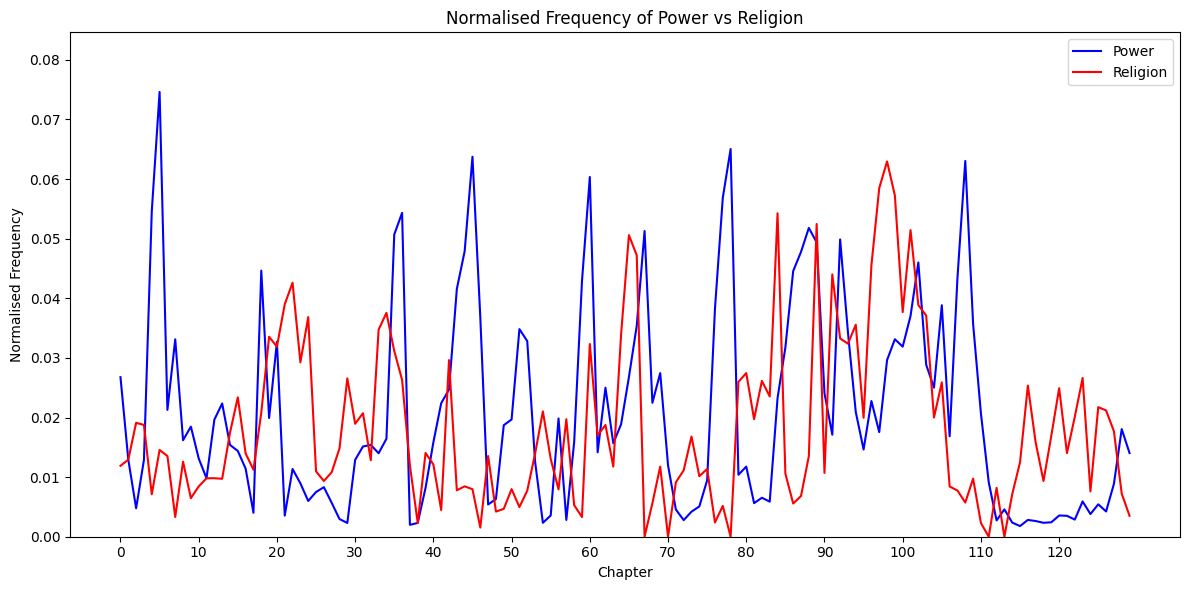

In [7]:
def plot_2_themes_by_document_normalized(
    theme_freq_by_doc1, theme_freq_by_doc2,
    theme_name1, theme_name2,
    corpus_dict
):
    theme_counts1 = []
    theme_counts2 = []

    for i in range(130):
        doc_id = f"chapter_{i}"
        
        doc_length = len(corpus_dict[doc_id])
        
        if doc_length == 0:
            theme_counts1.append(0)
            theme_counts2.append(0)
            continue
        
        count1 = sum(theme_freq_by_doc1[doc_id].values()) / doc_length
        count2 = sum(theme_freq_by_doc2[doc_id].values()) / doc_length
        
        theme_counts1.append(count1)
        theme_counts2.append(count2)

    doc_ids = list(range(130))

    plt.figure(figsize=(12, 6))
    
    plt.plot(doc_ids, theme_counts1, color='blue', label=theme_name1)
    plt.plot(doc_ids, theme_counts2, color='red', label=theme_name2)
    plt.xlabel('Chapter')
    plt.ylabel('Normalised Frequency')
    plt.title(f'Normalised Frequency of {theme_name1} vs {theme_name2}')
    plt.ylim(0, max(max(theme_counts1), max(theme_counts2)) + 0.01)
    plt.xticks(range(0, 130, 10)) 
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"concept_word_images/{theme_name1}_vs_{theme_name2}_normalized_by_chapter.png", dpi=500)
    plt.show()

plot_2_themes_by_document_normalized(
    power_freq_by_doc,
    religion_freq_by_doc,
    "Power",
    "Religion",
    lemmas
)